In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from matplotlib import gridspec
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})
from bumps.names import Parameter
from bumps.fitters import fit

from sasmodels.core import load_model
from sasmodels.bumps_model import Model, Experiment

import bumps
import sasmodels

In [61]:
def read_DAT_file(name):
    with open(name) as pdbfile:
        q = []
        I = []
        dI = []
        start = 10000
        for i,line in enumerate(pdbfile):
            if 'q(A-1)' in line:
                start = i
            if i > start: 
                splitted_line = [line[0:20], line[23:50], line[50:]]
                q.append(splitted_line[0])
                I.append(splitted_line[1])
                dI.append(splitted_line[2])
        q = np.array([float(i) for i in q])
        I = np.array([float(i) for i in I])
        dI = np.array([float(i) for i in dI])
        data = np.hstack((q.reshape(-1,1), I.reshape(-1,1), dI.reshape(-1,1)))
    return data

def convert_data(data, model):
    model_x = model[:,0]
    model_y = model[:,1]
    index = np.linspace(0, len(model_x)-1, len(model_x)) 
    model_q_new = []
    model_I_new = []
    for i in range(len(data)):
        data_q = data[i,0]
        array = np.abs(model_x - data_q)
        array = np.hstack((array.reshape(-1,1), index.reshape(-1,1)))
        array = array[np.argsort(array[:, 0])]
        loc = int(array[0,1])
        model_q_new.append(model_x[loc])
        model_I_new.append(model_y[loc])
    q = np.array(model_q_new).reshape(-1,1)
    I = np.array(model_I_new).reshape(-1,1)
    new_model_data = np.hstack((q, I))
    return new_model_data






def normalize_scattering_curves(q, I1, I2, q_min, q_max):
    """
    Normalizes the second scattering curve to match the first within the q-range [q_min, q_max].

    Parameters:
        data (np.ndarray): 2D array with shape (N, 3), where
                           - column 0: q values,
                           - column 1: intensity of curve 1,
                           - column 2: intensity of curve 2
        q_min (float): lower bound of q-range for normalization
        q_max (float): upper bound of q-range for normalization

    Returns:
        np.ndarray: New array with same shape as input, with column 2 normalized
    """
    # Mask to select points within the given q-range
    mask = (q >= q_min) & (q <= q_max)
    if not np.any(mask):
        raise ValueError("No data points found within the specified q-range.")
    # Calculate normalization factor
    scale_factor = np.mean(I1[mask]) / np.mean(I2[mask])
    # Apply normalization
    I2_normalized = I2 * scale_factor
    # Return the combined array
    return I2_normalized


def calculate_structure_factor(data0, data2, q_min, q_max, plot):
    new_data_2 = convert_data(data0, data2)
    fig, ax = plt.subplots(figsize=(7,7))
    normalized_data = normalize_scattering_curves(new_data_2[:,0], new_data_2[:,1], data0[:,1], q_min, q_max)
    plt.scatter(data0[:,0], normalized_data, color = 'blue', label = 'data0')
    plt.scatter(new_data_2[:,0], new_data_2[:,1], color = 'red', label = 'data2')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel('Intensity (arb. unit)')
    plt.xlabel('q ($\\AA^{-1}$)')
    if plot == False:
        plt.close()
    structure_factor = new_data_2[:,1]/((normalized_data))
    structure_factor = np.hstack((new_data_2[:,0].reshape(-1,1), structure_factor.reshape(-1,1)))
    return structure_factor


In [62]:
#Load data for bilayer 
path = '../Data/SAXS/Longer Bridge/'
filenames = os.listdir(path)
data_20_bridge = np.load(path + 'Bridge_20.npy')
data_40_bridge = np.load(path + 'Bridge_40.npy')
data_80_bridge = np.load(path + 'Bridge_80.npy')
cp_agg = np.load(path + 'close_packed_aggregates.npy')
sphere_polydisperse = np.loadtxt(path + 'sasmodels_sphere_fit.txt', skiprows=1)

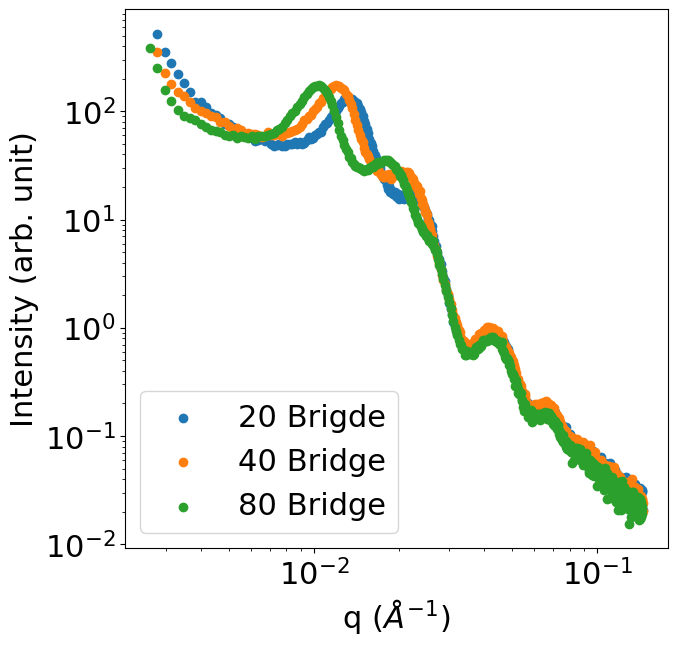

In [63]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(data_20_bridge[:,0], data_20_bridge[:,1], color = 'C0', label = '20 Brigde')
plt.scatter(data_40_bridge[:,0], data_40_bridge[:,1], color = 'C1', label = '40 Bridge')
plt.scatter(data_80_bridge[:,0], data_80_bridge[:,1], color = 'C2', label = '80 Bridge')
#plt.scatter(cp_agg[:,0], cp_agg[:,1], color = 'black', label = '80 Bridge')

# plt.scatter([data_20_bridge[np.argmax(data_20_bridge[20:,1])+20][0]], [100], marker = 'x', s = 300, color ='k')
# plt.scatter([data_40_bridge[np.argmax(data_40_bridge[20:,1])+20][0]], [100], marker = 'x', s = 300, color ='k')
#plt.scatter([0.0136], [50], marker = 'x', s = 300, color ='k')
#plt.vlines(0.032, 1e-4, 1e2, color='k')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Intensity (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
plt.legend()
#plt.savefig('../Figures/Brigde_length.png', dpi=600, bbox_inches="tight")

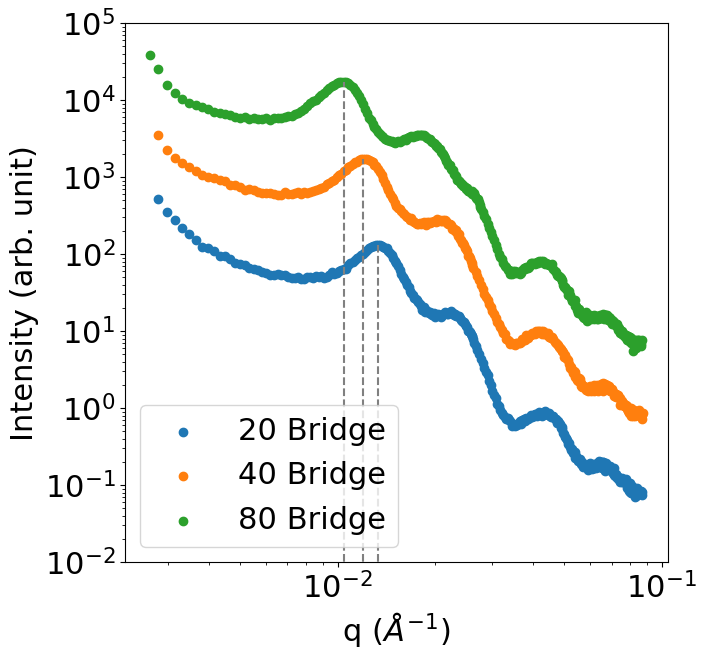

In [64]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(data_20_bridge[:-170,0], data_20_bridge[:-170,1], color = 'C0', label = '20 Bridge')
plt.scatter(data_40_bridge[:-170,0], data_40_bridge[:-170,1]*1e1, color = 'C1', label = '40 Bridge')
plt.scatter(data_80_bridge[:-170,0], data_80_bridge[:-170,1]*1e2, color = 'C2', label = '80 Bridge')
#plt.scatter(cp_agg[:,0], cp_agg[:,1], color = 'black', label = '80 Bridge')

#simulation_20 = np.load('../Data/Simulations/Bridge 20 Structure Factor/Sample_52_good/Density_0.005_U_0_46.95262_r0_2.25_n_1.0_m_20.89932/scattering_data_intensity/Intensity_plot-1.npy')
#simulation_40 = np.load('../Data/Simulations/Bridge 40 Structure Factor/Sample_67_Best/Density_0.005_U_0_81.42227_r0_2.42687_n_21.78117_m_1.0/scattering_data_intensity/Intensity_plot-1.npy')
#simulation_80 = np.load('../Data/Simulations/Bridge 80 Structure Factor/Sample_44_Best/Density_0.005_U_0_7.46293_r0_2.86209_n_30.0_m_1.0/scattering_data_intensity/Intensity_plot-1.npy')

#plt.plot(simulation_20[:,0], simulation_20[:,1]*0.5, linewidth = 5, label = '20 Bridge', color = 'purple')
#plt.plot(simulation_40[:,0], simulation_40[:,1]*0.5e1, linewidth = 5, label = '40 Bridge', color = 'green')
#plt.plot(simulation_80[:,0], simulation_80[:,1]*0.3e2, linewidth = 5, label = '80 Bridge', color = 'black')

p1 = data_20_bridge[np.argmax(data_20_bridge[10:100,1]) + 10, 0]
plt.vlines(p1, 1e-3, np.max(data_20_bridge[10:100,1]), color='gray', linestyles='--')
p2 = data_40_bridge[np.argmax(data_40_bridge[10:100,1]) + 10, 0]
plt.vlines(p2, 1e-3, np.max(data_40_bridge[10:100,1])*1e1, color='gray', linestyles='--')
p3 = data_80_bridge[np.argmax(data_80_bridge[10:100,1]) + 10, 0]
plt.vlines(p3, 1e-3, np.max(data_80_bridge[10:100,1]*1e2), color='gray', linestyles='--')

plt.xscale('log')
plt.yscale('log')
plt.ylabel('Intensity (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
plt.ylim([1e-2, 1e5])
plt.legend()
#plt.savefig('../Figures/Brigde_length.png', dpi=600, bbox_inches="tight")

In [65]:
struc_factor = calculate_structure_factor(sphere_polydisperse, data_20_bridge, 0.02, 0.03, False)
struc_factor_2 = calculate_structure_factor(sphere_polydisperse, data_40_bridge, 0.02, 0.03, False)
struc_factor_3 = calculate_structure_factor(sphere_polydisperse, data_80_bridge, 0.02, 0.03, False)
struc_factor_4 = calculate_structure_factor(sphere_polydisperse, cp_agg, 0.02, 0.03, False)

In [66]:
# np.save('../Data/SAXS/Structure Factors/Bridge_20_SF.npy', struc_factor)
# np.save('../Data/SAXS/Structure Factors/Bridge_40_SF.npy', struc_factor_2)
# np.save('../Data/SAXS/Structure Factors/Bridge_80_SF.npy', struc_factor_3)
#np.save('../Data/SAXS/Structure Factors/cp_agg_SF.npy', struc_factor_4)

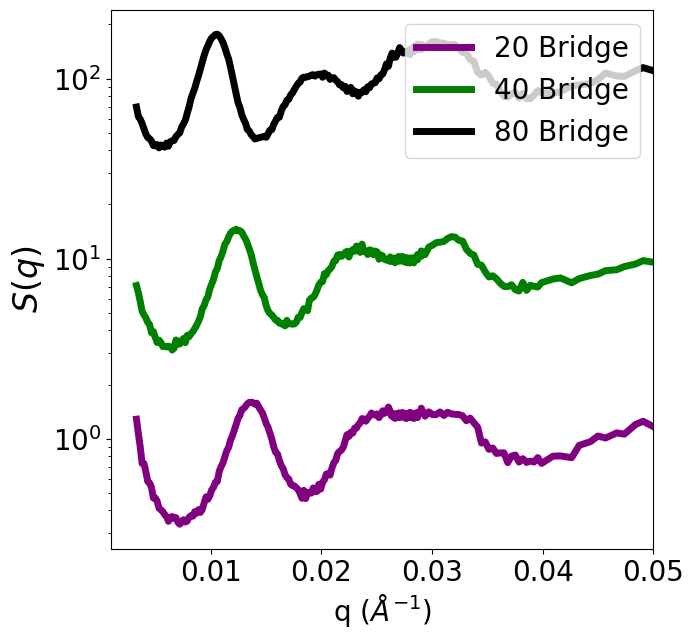

In [67]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7,7))
#plt.scatter(data0[:,0], data5)
#plt.scatter(q, data5)
plt.plot(struc_factor[:,0], struc_factor[:,1], linewidth = 5, label = '20 Bridge', color = 'purple')
plt.plot(struc_factor_2[:,0], struc_factor_2[:,1]*10, linewidth = 5, label = '40 Bridge', color = 'green')
plt.plot(struc_factor_3[:,0], struc_factor_3[:,1]*100, linewidth = 5, label = '80 Bridge', color = 'black')

# p1 = struc_factor[np.argmax(struc_factor[10:100,1]) + 10, 0]
# plt.vlines(p1, 1e-4, 1e2, color='gray', linestyles='--')
# p2 = struc_factor_2[np.argmax(struc_factor_2[10:100,1]) + 10, 0]
# plt.vlines(p2, 1e-4, 1e2, color='gray', linestyles='--')
# p3 = struc_factor_3[np.argmax(struc_factor_3[10:100,1]) + 10, 0]
# plt.vlines(p3, 1e-4, 1e2, color='gray', linestyles='--')


plt.xlim([0.001, 0.05])
#plt.ylim([0, 80])
plt.yscale('log')
#plt.xticks([0.02, 0.03, 0.04])
plt.ylabel('$S(q)$', fontsize=24)
plt.xlabel('q ($\\AA^{-1}$)')
plt.legend()
#plt.savefig('../Figures/Structure_Factor_with_lines.png', dpi=600, bbox_inches="tight")

In [68]:
## Load the best fits from the simulations
#simulation_20 = np.load('../Data/Simulations/Bridge 20/Sample_24_Best_Sample/Density_0.00323_U_0_100.0_r0_2.13904_n_16.98738/scattering_data/average_scattering_curve.npy')
#simulation_40 = np.load('../Data/Simulations/Bridge 40/Sample_65_BEST/Density_0.00341_U_0_37.74001_r0_2.45_n_0.1/scattering_data/average_scattering_curve.npy')
#simulation_40 = np.load('../Data/Simulations/Bridge 40 Structure Factor/Sample_37_Good_one/Density_0.00351_U_0_2.92543_r0_2.54106_n_7.26752_m_29.85751/scattering_data_intensity/Intensity_plot-5.npy')
#simulation_80 = np.load('../Data/Simulations/Bridge 80/Sample_78_Best_Sample/Density_0.00422_U_0_53.0424_r0_2.87356_n_0.1/scattering_data/average_scattering_curve.npy')

In [28]:
simulation_005 = np.load('../Data/Simulations/Density Simulation/Optimization_Results/Sample_0/Density_0.005_U_0_81.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_001 = np.load('../Data/Simulations/Density Simulation/Optimization_Results/Sample_1/Density_0.001_U_0_81.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_0005 = np.load('../Data/Simulations/Density Simulation/Optimization_Results/Sample_2/Density_0.0005_U_0_81.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')

In [74]:
simulation_U0_0 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_0/Density_0.005_U_0_81.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_1 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_1/Density_0.005_U_0_76.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_2 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_2/Density_0.005_U_0_71.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_3 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_3/Density_0.005_U_0_61.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_4 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_4/Density_0.005_U_0_51.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_5 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_5/Density_0.005_U_0_41.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_6 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_6/Density_0.005_U_0_31.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_7 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_7/Density_0.005_U_0_21.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')
simulation_U0_8 = np.load('../Data/Simulations/U0 Simulation/EXP251009_U0/Optimization_Results/Sample_8/Density_0.005_U_0_11.42_r0_2.42_n_1.0_m_21.78/scattering_data_intensity/Intensity_plot-5.npy')

In [75]:
def sphere(q, r):
    return 3*(np.sin(q*r) - q*r*np.cos(q*r))**2/(q*r)**6
q = np.geomspace(0.003, 0.08, 500)
I_sphere = sphere(q, 130)
monodisperse_sphere = np.hstack((q.reshape(-1,1), I_sphere.reshape(-1,1)))

In [76]:
struc_factor_0 = calculate_structure_factor(monodisperse_sphere, simulation_U0_0, 0.01, 0.02, False)
struc_factor_1 = calculate_structure_factor(monodisperse_sphere, simulation_U0_1, 0.01, 0.02, False)
struc_factor_2 = calculate_structure_factor(monodisperse_sphere, simulation_U0_2, 0.01, 0.02, False)
struc_factor_3 = calculate_structure_factor(monodisperse_sphere, simulation_U0_3, 0.01, 0.02, False)
struc_factor_4 = calculate_structure_factor(monodisperse_sphere, simulation_U0_4, 0.01, 0.02, False)
struc_factor_5 = calculate_structure_factor(monodisperse_sphere, simulation_U0_5, 0.01, 0.02, False)
struc_factor_6 = calculate_structure_factor(monodisperse_sphere, simulation_U0_6, 0.01, 0.02, False)
struc_factor_7 = calculate_structure_factor(monodisperse_sphere, simulation_U0_7, 0.01, 0.02, False)
struc_factor_8 = calculate_structure_factor(monodisperse_sphere, simulation_U0_8, 0.01, 0.02, False)

In [42]:
struc_factor_005 = calculate_structure_factor(monodisperse_sphere, simulation_005, 0.01, 0.02, False)
struc_factor_001 = calculate_structure_factor(monodisperse_sphere, simulation_001, 0.01, 0.02, False)
struc_factor_0005 = calculate_structure_factor(monodisperse_sphere, simulation_0005, 0.01, 0.02, False)
#struc_factor_80 = calculate_structure_factor(monodisperse_sphere, simulation_80, 0.02, 0.03, False)

In [ ]:
# np.save('../Data/Simulations/Density Simulation Structure Factor/structure_factor_005.npy', struc_factor_005)
# np.save('../Data/Simulations/Density Simulation Structure Factor/structure_factor_001.npy', struc_factor_001)
# np.save('../Data/Simulations/Density Simulation Structure Factor/structure_factor_0005.npy', struc_factor_0005)

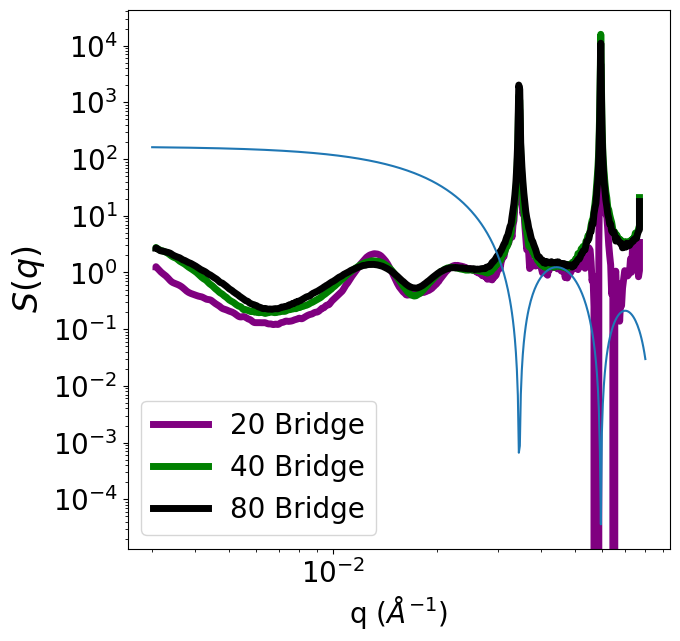

In [44]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7,7))
plt.plot(struc_factor_005[:,0], struc_factor_005[:,1], linewidth = 5, label = '20 Bridge', color = 'purple')
plt.plot(struc_factor_001[:,0], struc_factor_001[:,1], linewidth = 5, label = '40 Bridge', color = 'green')
plt.plot(struc_factor_0005[:,0], struc_factor_0005[:,1], linewidth = 5, label = '80 Bridge', color = 'black')
plt.plot(q, I_sphere*5e2)
# plt.xlim([0.001, 0.05])
# plt.ylim([0, 80])
plt.ylabel('$S(q)$', fontsize=24)
plt.xlabel('q ($\\AA^{-1}$)')
plt.legend()
plt.xscale('log')
plt.yscale('log')
#plt.savefig('../Figures/Structure_Factor_with_lines.png', dpi=600, bbox_inches="tight")

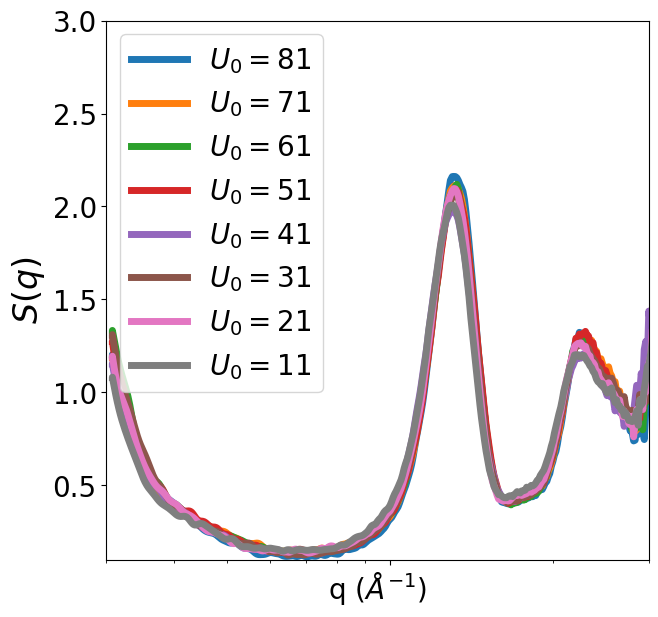

In [83]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7,7))
#plt.scatter(data0[:,0], data5)
#plt.scatter(q, data5)
plt.plot(struc_factor_0[:,0], struc_factor_0[:,1], linewidth = 5, label = '$U_{0} = 81$')
#plt.plot(struc_factor_1[:,0], struc_factor_1[:,1], linewidth = 5, label = 'Num. Density = 0.001')
plt.plot(struc_factor_2[:,0], struc_factor_2[:,1], linewidth = 5, label = '$U_{0} = 71$')
plt.plot(struc_factor_3[:,0], struc_factor_3[:,1], linewidth = 5, label = '$U_{0} = 61$')
plt.plot(struc_factor_4[:,0], struc_factor_4[:,1], linewidth = 5, label = '$U_{0} = 51$')
plt.plot(struc_factor_5[:,0], struc_factor_5[:,1], linewidth = 5, label = '$U_{0} = 41$')
plt.plot(struc_factor_6[:,0], struc_factor_6[:,1], linewidth = 5, label = '$U_{0} = 31$')
plt.plot(struc_factor_7[:,0], struc_factor_7[:,1], linewidth = 5, label = '$U_{0} = 21$')
plt.plot(struc_factor_8[:,0], struc_factor_8[:,1], linewidth = 5, label = '$U_{0} = 11$')

plt.xlim([0.003, 0.030])
plt.ylim([0.1, 3])
#plt.yscale('log')
plt.xscale('log')
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
#plt.xticks([0.02, 0.03, 0.04])
plt.ylabel('$S(q)$', fontsize=24)
plt.xlabel('q ($\\AA^{-1}$)')
plt.legend()
#plt.savefig('../Figures/Structure_Factor_Number_Density.png', dpi=600, bbox_inches="tight")

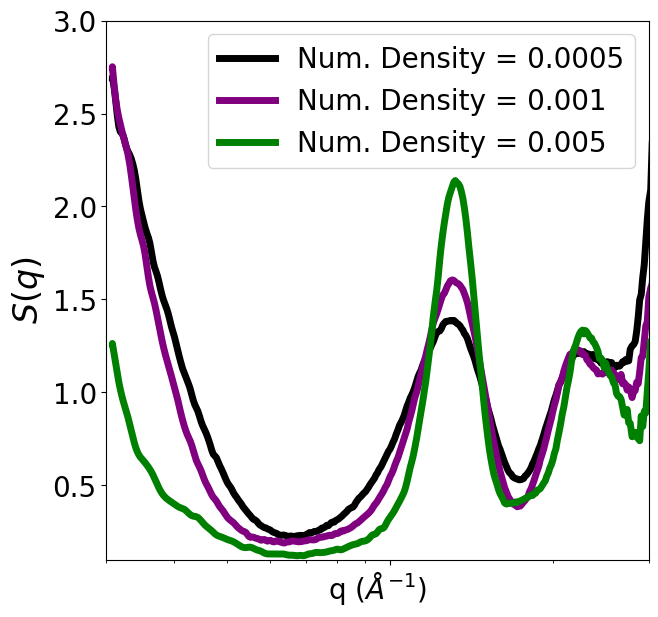

In [ ]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7,7))
#plt.scatter(data0[:,0], data5)
#plt.scatter(q, data5)
plt.plot(struc_factor_0005[:,0], struc_factor_0005[:,1], linewidth = 5, label = 'Num. Density = 0.0005', color = 'black')
plt.plot(struc_factor_001[:,0], struc_factor_001[:,1], linewidth = 5, label = 'Num. Density = 0.001', color = 'purple')
plt.plot(struc_factor_005[:,0], struc_factor_005[:,1], linewidth = 5, label = 'Num. Density = 0.005', color = 'green')


#plt.plot(struc_factor[:,0], struc_factor[:,1]*100, linewidth = 5, label = '20 Bridge exp', color = 'gray')
#plt.plot(struc_factor_2[:,0], struc_factor_2[:,1], linewidth = 6, label = '40 Bridge exp', color = 'red')
#plt.plot(struc_factor_3[:,0], struc_factor_3[:,1], linewidth = 5, label = '80 Bridge exp', color = 'blue')



plt.xlim([0.003, 0.030])
plt.ylim([0.1, 3])
#plt.yscale('log')
plt.xscale('log')
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
#plt.xticks([0.02, 0.03, 0.04])
plt.ylabel('$S(q)$', fontsize=24)
plt.xlabel('q ($\\AA^{-1}$)')
plt.legend()
#plt.savefig('../Figures/Structure_Factor_Number_Density.png', dpi=600, bbox_inches="tight")